In [1]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine(
    "",
    connect_args={"sslmode": "require"}
)

In [2]:
df = pd.read_sql(
    'SELECT * FROM "TotalEmissionSO2s";',
    engine
)
df

,Id,Year,Total,Combustion_processes,Production_processes,Transport,Other
0,17,2006,141034.0,100477.0,36061.0,515.0,3981.0
1,18,2007,147904.0,100800.0,37120.0,5760.0,4224.0
2,19,2008,109853.0,95168.0,13654.0,1024.0,7.0
3,20,2009,113574.0,99593.0,12990.0,818.0,173.0
4,21,2010,83152.0,80213.0,2916.0,20.0,3.0
5,22,2011,101070.0,98123.0,2924.0,20.0,3.0
6,23,2012,89390.0,86209.0,3050.0,131.0,1.0
7,24,2013,82205.0,77474.0,4723.0,7.0,2.0
8,25,2014,82717.0,82674.0,5.0,36.0,2.0
9,26,2015,75033.0,74985.0,13.0,32.0,2.0


In [17]:
df = df.drop(columns=["Id"])
columns_to_model = df.columns.drop("Year")
future_years = pd.DataFrame({"Year": [2022, 2023, 2024, 2025, 2026, 2027, 2028]})

In [18]:
import os

os.makedirs("../models/TotalEmissionSO2s", exist_ok=True)

In [19]:
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.linear_model import Ridge
import joblib
import pandas as pd

forecasts = {}
best_params = {}
loo = LeaveOneOut()

for col in columns_to_model:
    X = df[["Year"]].values
    y = df[col].values

    ridge = Ridge()
    param_grid = {
        "alpha": [0.01, 0.1, 1, 10],
        "fit_intercept": [True, False]
    }

    grid = GridSearchCV(ridge, param_grid, cv=loo, scoring='neg_mean_squared_error')
    grid.fit(X, y)

    best_model = grid.best_estimator_
    best_params[col] = grid.best_params_

    pred = best_model.predict(future_years[["Year"]].values)
    forecasts[col] = pred

    joblib.dump(best_model, f"../models/TotalEmissionSO2s/{col}_ridge_model.pkl")

df_forecast = pd.DataFrame(forecasts, index=future_years["Year"])
print(df_forecast)

print("Best parameters per column:")
for col, params in best_params.items():
    print(f"{col}: {params}")


             Total  Combustion_processes  Production_processes    Transport  \
Year                                                                          
2022  65345.057143          86004.988431          -9104.767143  -664.544286   
2023  61993.328571          86047.523045         -11012.798571  -806.167143   
2024  58641.600000          86090.057658         -12920.830000  -947.790000   
2025  55289.871429          86132.592272         -14828.861429 -1089.412857   
2026  51938.142857          86175.126885         -16736.892857 -1231.035714   
2027  48586.414286          86217.661499         -18644.924286 -1372.658571   
2028  45234.685714          86260.196112         -20552.955714 -1514.281429   

            Other  
Year               
2022  -884.226429  
2023 -1050.120714  
2024 -1216.015000  
2025 -1381.909286  
2026 -1547.803571  
2027 -1713.697857  
2028 -1879.592143  
Best parameters per column:
Total: {'alpha': 10, 'fit_intercept': True}
Combustion_processes: {'alpha': 10, 

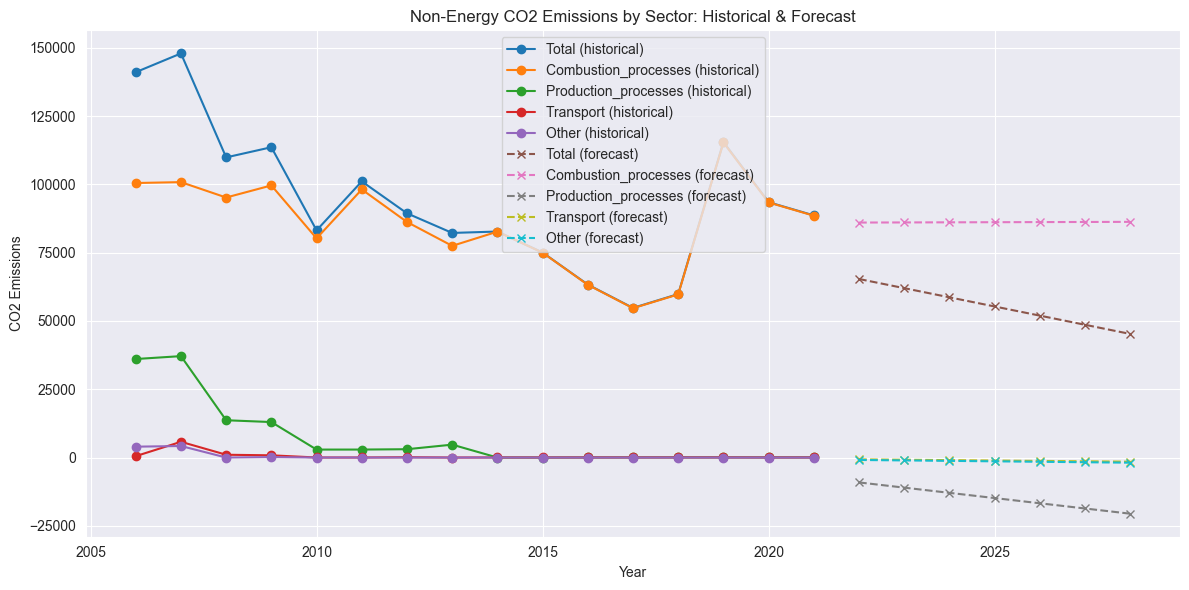

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for col in columns_to_model:
    plt.plot(df["Year"], df[col], marker='o', label=f"{col} (historical)")

for col in columns_to_model:
    plt.plot(future_years["Year"], df_forecast[col], marker='x', linestyle='--', label=f"{col} (forecast)")

plt.title("Non-Energy CO2 Emissions by Sector: Historical & Forecast")
plt.xlabel("Year")
plt.ylabel("CO2 Emissions")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
